# Лаба 1.02

Введите ***личные данные*** и ***результаты измерений***

In [68]:
profile={
    # Титульник
    "group": "K3121",
    "student": "Сакулин Иван",
    "teacher": "Курашова С.А.",
    "date": "03.03.2025",
    
    # Пути к графикам
    "path_schema": "1.02.physics-cheme.png",
    "path_g1": "1.02.g1.png",
    "path_g2":"1.02.g2.png",
}

output_path = "./output_1.02/"


### Математические функции и XML

In [69]:
from pathlib import Path
Path(output_path).mkdir(parents=True, exist_ok=True)

from meas import *
from math import *
from pprint import pprint

### Результаты измерений

In [70]:
# (Таблица 1) Погрешности приборов: [delta_x] м; [delta_h] мм; [delta_t] с
delta_x = 0.005
delta_h = 0.5 # мм
delta_t = 0.1
# (Таблица 2) Горизонтальное положение: [x] м, [x'] м; [h] мм, [h'] мм
x = 0.220
X = 1.000 
h0 = 180
H0 = 181
# (Таблица 3) Измерения задания 1: [x1] м | [x2] м | [t1] с | [t2] с
data1 = [
    (0.15, 0.40, 1.3, 2.4),
    (0.15, 0.50, 1.2, 2.7),
    (0.15, 0.70, 1.3, 3.3),
    (0.15, 0.90, 1.2, 3.7),
    (0.15, 1.10, 1.3, 4.2)
]
# (Таблица 4) Измерения задания 2: [h1] мм | [h2] мм | [t1] с | [t2] с
data2 = [
    (191, 182, [1.2, 1.2, 1.2, 1.3, 1.3], [4.2, 4.2, 4.2, 4.2, 4.2]),
    (200, 183, [0.9, 0.9, 0.9, 0.9, 0.9], [3.0, 3.0, 3.0, 3.0, 3.0]),
    (210, 184, [0.7, 0.7, 0.7, 0.7, 0.7], [2.4, 2.4, 2.4, 2.4, 2.5]),
    (219, 184, [0.6, 0.6, 0.6, 0.6, 0.6], [2.1, 2.1, 2.1, 2.1, 2.1]),
    (229, 185, [0.5, 0.5, 0.6, 0.6, 0.5], [1.9, 1.9, 1.9, 1.9, 1.9])
]
# Координаты ворот задания 2
lol_x1 = 0.15
lol_x2 = 1.10

### Рассчёты

##### Задание 1.1 и 1.3

In [ ]:
Y, Z = [], []
for i, (x1, x2, t1, t2) in enumerate(data1):
    Y.append(Measurement(x2-x1, (2*sqrt(2)/3) * delta_x))
    Z.append(Measurement((t2**2 - t1**2) / 2, (2/3) * delta_t * sqrt(t2**2 + t1**2)))

print(Y, Z, sep="\n")


[0.250, Δ = 0.005, ε = 1.9, 0.350, Δ = 0.005, ε = 1.3, 0.550, Δ = 0.005, ε = 0.9, 0.750, Δ = 0.005, ε = 0.6, 0.950, Δ = 0.005, ε = 0.5]
[3.73, Δ = 0.18, ε = 5, 4.37, Δ = 0.20, ε = 5, 6.29, Δ = 0.24, ε = 3.8, 7.57, Δ = 0.26, ε = 3.4, 9.67, Δ = 0.29, ε = 3.0]


In [72]:
N = len(data1)
value_a = sum(Y[i].value*Z[i].value for i in range(N)) / sum(Z[i].value**2 for i in range(N))
sigma_a = sqrt(sum((Y[i].value-value_a*Z[i].value)**2 for i in range(N)) / sum(Z[i].value**2 for i in range(N)) / (N - 1))
a = Measurement(value_a, 2*sigma_a)
print(a.rounded)
print(sigma_a)

0.093, Δ = 0.009, ε = 10
0.004543272246253794


##### Задание 1.2 и 1.4

График зависимости: Y = -0.1779972338575152+0.1183165507525333Z


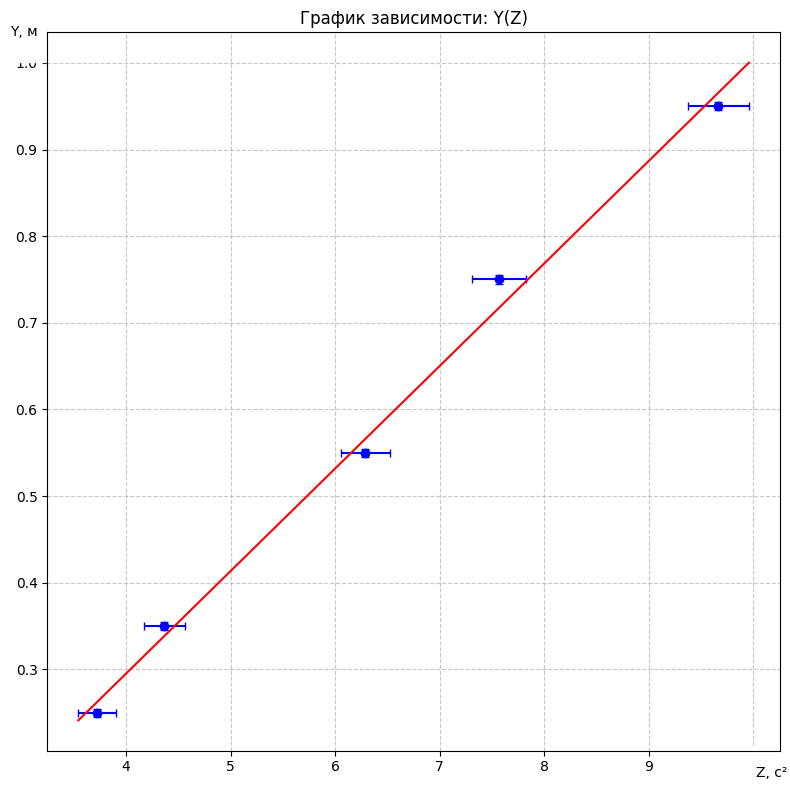

In [73]:
Z_Y = LinearMultipleMeasurement(Z, Y)

Drawer.plot_dependency(Z_Y,
    x_name='Z', x_unit='с²', y_name='Y', y_unit='м',
    error_X=True, error_Y=True,
    output_path=output_path + profile["path_g1"]
)

##### Задание 2.1 - 2.4

In [74]:
sin_alpha = []
for (h, H, t1, t2) in data2:
    sa = abs( ((h0 - h) - (H0 - H)) / (X*1000 - x*1000) )
    sin_alpha.append(sa)

pprint(sin_alpha)

[0.01282051282051282,
 0.023076923076923078,
 0.03461538461538462,
 0.046153846153846156,
 0.057692307692307696]


In [75]:
average_t1 = []
average_t2 = []
for (h, H, t1_values, t2_values) in data2:
    t1 = DirectMultipleMeasurement(t1_values, delta_t)
    t2 = DirectMultipleMeasurement(t2_values, delta_t)
    average_t1.append(t1)
    average_t2.append(t2)
    
pprint(average_t1)
pprint(average_t2)
print(average_t1[0])

[1.24, Δ = 0.10, ε = 8,
 0.90, Δ = 0.07, ε = 7,
 0.70, Δ = 0.07, ε = 10,
 0.60, Δ = 0.07, ε = 11,
 0.54, Δ = 0.10, ε = 18]
[4.20, Δ = 0.07, ε = 1.6,
 3.00, Δ = 0.07, ε = 2.2,
 2.42, Δ = 0.09, ε = 3.6,
 2.10, Δ = 0.07, ε = 3.2,
 1.90, Δ = 0.07, ε = 3.5]

N = 5
values = [1.2, 1.2, 1.2, 1.3, 1.3]
average = 1.24 ± 0.10, ε=8% (1.24, Δ = 0.0952968228454887, ε = 7.685227648829733)
sigma_ = 0.024494897427831803
delta_instrumental = 0.1
delta_random_ = 0.06809581484937241
student = 2.78


In [76]:
average_a = []
for i in range(len(data2)):
    t1, t2 = average_t1[i], average_t2[i]
    avr_a = 2 * (lol_x2 - lol_x1) / (t2.value**2 - t1.value**2)
    del_a = avr_a * sqrt((2*delta_x**2)/(lol_x2 - lol_x1)**2 + 4*((t1.value*t1.delta)**2 + (t2.value*t2.delta)**2)/(t2.value**2 - t1.value**2)**2)
    average_a.append(Measurement(avr_a, del_a))
    
pprint(average_a)

[0.118, Δ = 0.005, ε = 3.8,
 0.232, Δ = 0.012, ε = 5,
 0.354, Δ = 0.029, ε = 8,
 0.469, Δ = 0.034, ε = 7,
 0.57, Δ = 0.05, ε = 8]


##### Задание 2.5 - 2.7

In [77]:
S_A = LinearMultipleMeasurement( 
    [Measurement(sa, 0) for sa in sin_alpha],
    average_a
)

print(S_A.a)
print(S_A.b)

-0.005, Δ = 0.018, ε = 370 (-0.0049089653151363, Δ = 0.0181570449064885, ε = 369.8751924464226)
10.2, Δ = 0.5, ε = 5 (10.153108849665138, Δ = 0.4734529017671089, ε = 4.6631323349076865)


In [78]:
avg_a = [avg_a.value for avg_a in average_a]
N = len(avg_a)
d = [avg_a[i] - (S_A.a.value + S_A.b.value*sin_alpha[i]) for i in range(N)]
sum_d2 = sum(d[i]**2 for i in range(N))
D = sum(sin_alpha[i]**2 for i in range(N)) - (1/N)*(sum(sin_alpha))**2
sigma_g = sqrt(sum_d2/D/(N-2))
print(d, D, sigma_g)

[-0.007264263791695286, 0.002596685390018949, 0.0075100573109256885, 0.005439743953573384, -0.00828222286282243] 0.0012735042735042721 0.2367264508835589


In [79]:
g = S_A.b
print(g)

10.2, Δ = 0.5, ε = 5 (10.153108849665138, Δ = 0.4734529017671089, ε = 4.6631323349076865)


In [80]:
g_table = 9.81908
g_table_delta = Measurement.round_error(abs(g.value - g_table))[0]
g_table_epsilon = Measurement.round_error(g_table_delta / g.value * 100)[0]
print(f'g табл = {g_table}, Δ = {g_table_delta}, ε = {g_table_epsilon}')

g табл = 9.81908, Δ = 0.33, ε = 3.3


##### Задание 2.8 - 2.9

График зависимости: sin α = -0.0049089653151363+10.153108849665138a


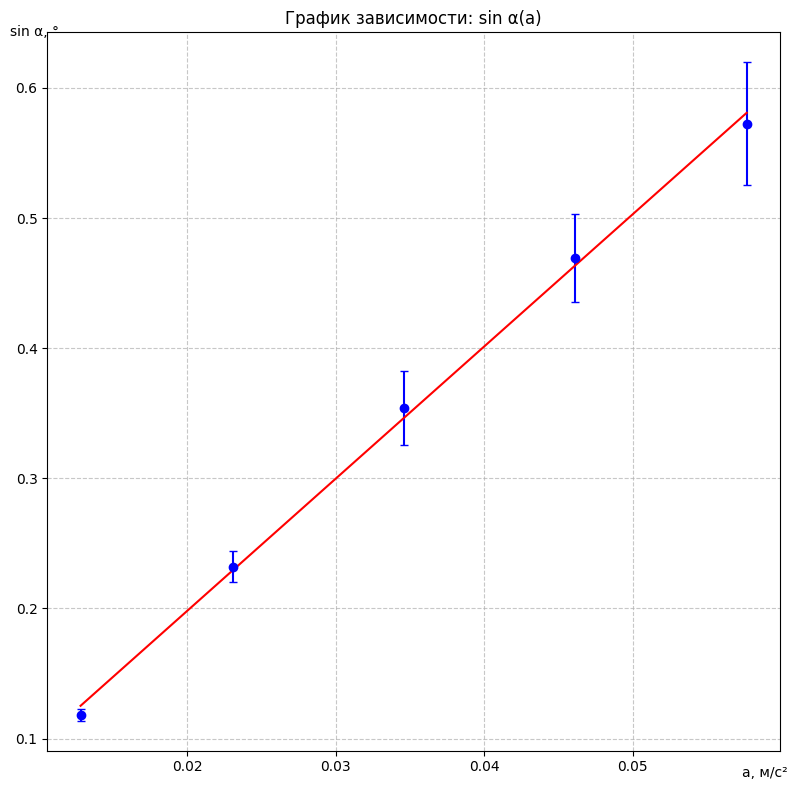

In [81]:
Drawer.plot_dependency(S_A,
    x_name='a', x_unit='м/с²', y_name='sin α', y_unit='°',
    error_X=True, error_Y=True,
    output_path=output_path + profile["path_g2"]
)

### LaTeX generator

In [82]:
table2 = f"${Measurement(x, delta_x).latex_std(cl=False)}$ & ${Measurement(X, delta_x).latex_std(cl=False)}$ & ${Measurement(h0, delta_h).latex_std(cl=False)}$ & ${Measurement(H0, delta_h).latex_std(cl=False)}$"

print(table2)

$0.220 \pm 0.005$ & $1.000 \pm 0.005$ & $180.0 \pm 0.5$ & $181.0 \pm 0.5$


In [83]:
table3 = ""
for (i, ((x1, x2, t1, t2), y, z)) in enumerate(zip(data1, Y, Z)):
    table3 += f'{i + 1} & {x1} & {x2} & {t1} & {t2} & ${y.latex_std(cl=False)}$ & ${z.latex_std(cl=False)}$ \\\\ \\hline\n'

print(table3)

1 & 0.15 & 0.4 & 1.3 & 2.4 & $0.250 \pm 0.005$ & $3.73 \pm 0.18$ \\ \hline
2 & 0.15 & 0.5 & 1.2 & 2.7 & $0.350 \pm 0.005$ & $4.37 \pm 0.20$ \\ \hline
3 & 0.15 & 0.7 & 1.3 & 3.3 & $0.550 \pm 0.005$ & $6.29 \pm 0.24$ \\ \hline
4 & 0.15 & 0.9 & 1.2 & 3.7 & $0.750 \pm 0.005$ & $7.57 \pm 0.26$ \\ \hline
5 & 0.15 & 1.1 & 1.3 & 4.2 & $0.950 \pm 0.005$ & $9.67 \pm 0.29$ \\ \hline



In [84]:
calculations_a = f"""По формулам были посчитаны $a = {a.str_value}\\text{{м}}/\\text{{c}}^2$ и $\\sigma_a \\approx {sigma_a:.5f}$.
Затем погрешности $\\delta_a = {a.str_delta}\\text{{м}}/\\text{{c}}^2$ и $\\varepsilon_a = {a.str_epsilon}\\%$ Результат:
"""
result_a =f"""\\begin{{equation*}}
a = {a.latex_std()}\\text{{м}}/\\text{{c}}^2, \\quad \\varepsilon_a = {a.str_epsilon}\\%, \\quad \\alpha=0.95
\\end{{equation*}}"""
print(calculations_a + result_a)

По формулам были посчитаны $a = 0.093\text{м}/\text{c}^2$ и $\sigma_a \approx 0.00454$.
Затем погрешности $\delta_a = 0.009\text{м}/\text{c}^2$ и $\varepsilon_a = 10\%$ Результат:
\begin{equation*}
a = (0.093 \pm 0.009)\text{м}/\text{c}^2, \quad \varepsilon_a = 10\%, \quad \alpha=0.95
\end{equation*}


In [85]:
table4 = ""
for i in range(len(data2)):
    table4 += f'{i + 1} & {sin_alpha[i]:.3f} & ${average_t1[i].latex_std(cl=0)}$ & ${average_t2[i].latex_std(cl=0)}$ & ${average_a[i].latex_std(cl=0)}$ \\\\ \\hline\n'

print(table4)

1 & 0.013 & $1.24 \pm 0.10$ & $4.20 \pm 0.07$ & $0.118 \pm 0.005$ \\ \hline
2 & 0.023 & $0.90 \pm 0.07$ & $3.00 \pm 0.07$ & $0.232 \pm 0.012$ \\ \hline
3 & 0.035 & $0.70 \pm 0.07$ & $2.42 \pm 0.09$ & $0.354 \pm 0.029$ \\ \hline
4 & 0.046 & $0.60 \pm 0.07$ & $2.10 \pm 0.07$ & $0.469 \pm 0.034$ \\ \hline
5 & 0.058 & $0.54 \pm 0.10$ & $1.90 \pm 0.07$ & $0.57 \pm 0.05$ \\ \hline



In [86]:
table5 = ""
for i, (h1, h2, t1, t2) in enumerate(data2):
    table5 += f'\\multirow{{5}}{{*}}{{{i + 1}}} & \\multirow{{5}}{{*}}{{{h1}}} & \\multirow{{5}}{{*}}{{{h2}}} & 1 & {t1[0]} & {t2[0]} '
    for j in range(1, len(t1)):
        table5 += f'\\\\ \\cline{{4-6}}\n& & & {j + 1} & {t1[j]} & {t2[j]} '
    table5 += '\\\\ \\hline\n'

print(table5)

\multirow{5}{*}{1} & \multirow{5}{*}{191} & \multirow{5}{*}{182} & 1 & 1.2 & 4.2 \\ \cline{4-6}
& & & 2 & 1.2 & 4.2 \\ \cline{4-6}
& & & 3 & 1.2 & 4.2 \\ \cline{4-6}
& & & 4 & 1.3 & 4.2 \\ \cline{4-6}
& & & 5 & 1.3 & 4.2 \\ \hline
\multirow{5}{*}{2} & \multirow{5}{*}{200} & \multirow{5}{*}{183} & 1 & 0.9 & 3.0 \\ \cline{4-6}
& & & 2 & 0.9 & 3.0 \\ \cline{4-6}
& & & 3 & 0.9 & 3.0 \\ \cline{4-6}
& & & 4 & 0.9 & 3.0 \\ \cline{4-6}
& & & 5 & 0.9 & 3.0 \\ \hline
\multirow{5}{*}{3} & \multirow{5}{*}{210} & \multirow{5}{*}{184} & 1 & 0.7 & 2.4 \\ \cline{4-6}
& & & 2 & 0.7 & 2.4 \\ \cline{4-6}
& & & 3 & 0.7 & 2.4 \\ \cline{4-6}
& & & 4 & 0.7 & 2.4 \\ \cline{4-6}
& & & 5 & 0.7 & 2.5 \\ \hline
\multirow{5}{*}{4} & \multirow{5}{*}{219} & \multirow{5}{*}{184} & 1 & 0.6 & 2.1 \\ \cline{4-6}
& & & 2 & 0.6 & 2.1 \\ \cline{4-6}
& & & 3 & 0.6 & 2.1 \\ \cline{4-6}
& & & 4 & 0.6 & 2.1 \\ \cline{4-6}
& & & 5 & 0.6 & 2.1 \\ \hline
\multirow{5}{*}{5} & \multirow{5}{*}{229} & \multirow{5}{*}{185} & 1 & 0.5 &

In [87]:
from jinja2 import Environment, FileSystemLoader

env = Environment(
    loader=FileSystemLoader("."),
    variable_start_string='<<',
    variable_end_string='>>',
    autoescape=False
)

template = env.get_template("template1.02.tex")

output = template.render(
    **profile,
    
    # Таблицы
    table2=table2,
    table3=table3,
    table4=table4,
    table5=table5,
    
    # Рассчёты
    calculations_a=calculations_a,
    result_a = result_a,
    
    h_0_value=h0/1000,
    h_value=h/1000,
    H_0_value=H0/1000,
    H_value=H/1000,
    X_value=format(X, '.2f'),
    x_value=format(x, '.2f'),
    sina_value=format(sin_alpha[0], '.3f'),
    t_1_value=average_t1[0].str_value,
    t_2_value=average_t2[0].str_value,
    a_value=average_a[0].str_value,
    
    g_exp=g.latex_std(),
    g_exp_eps=g.str_epsilon,
    g_table_delta=g_table_delta,
    g_table_eps=g_table_epsilon,
    
    # Погрешности
    x_delta=delta_x,
    Y_delta=Y[0].str_delta,
    Y_eps=[y.str_epsilon for y in Y],
    t_delta=delta_t,
    Z_delta=[z.str_delta for z in Z],
    Z_eps=[z.str_epsilon for z in Z],
    
    t11_sigma=format(average_t1[0]._sigma, '.4f'),
    t11_student=average_t1[0]._student,
    t11_delta_random=format(average_t1[0]._delta_random, '.4f'),
    t11_delta=average_t1[0].str_delta,
    t11_eps=average_t1[0].str_epsilon,
    
    a_delta=[z.str_delta for z in average_a],
    a_eps=[z.str_epsilon for z in average_a],
    d=[format(z, '.4f') for z in d],
    D=format(D, '.4f'),
    sigma_g=format(sigma_g, '.4f'),
    delta_g=g.str_delta,
    eps_g=g.str_epsilon,
    
    # Окончательные результаты
    res_a=a.latex_std(),
    res_a_eps=a.str_epsilon,
)

print(output)
with open(output_path + "report1.02.tex", "w", encoding="utf-8") as f:
    f.write(output)

\documentclass[14pt]{extreport}
\input{prop/preamble.inc}


\begin{document}

\SETgroup{K3121}
\SETstudent{Сакулин Иван}
\SETteacher{Курашова С.А.}
\SETdata{03.03.2025}
\SETnumber{1.02}
\SETtitle{Изучение скольжения тележки по наклонной плоскости}
\SETtitleT{}
\input{prop/title}

\noindent\textbf{1. Цель работы}

\begin{enumerate}[label=\arabic*)]
    \item Экспериментальная проверка равноускоренности движения
тележки по наклонной плоскости.
    \item Определение величины ускорения свободного падения $g$.
\end{enumerate}

\noindent\textbf{2. Задачи, решаемые при выполнении работы}

\begin{enumerate}[label=\arabic*)]
    \item Измерение времени движения тележки по рельсу с фиксированным углом наклона.
    \item Измерение времени движения тележки по рельсу при разных углах наклона рельса к горизонту.
    \item  Исследование движения тележки при фиксированном угле наклона рельса. Проверка равноускоренности движения тележки.
    \item  Исследование зависмости ускорения тележки от угла накл